In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1)

mnist

{'data':        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
 0           0       0       0       0       0       0       0       0       0   
 1           0       0       0       0       0       0       0       0       0   
 2           0       0       0       0       0       0       0       0       0   
 3           0       0       0       0       0       0       0       0       0   
 4           0       0       0       0       0       0       0       0       0   
 ...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
 69995       0       0       0       0       0       0       0       0       0   
 69996       0       0       0       0       0       0       0       0       0   
 69997       0       0       0       0       0       0       0       0       0   
 69998       0       0       0       0       0       0       0       0       0   
 69999       0       0       0       0       0       0       0       0       0   
 
      

In [2]:
X, y = mnist.data, mnist.target

X.shape, y.shape

((70000, 784), (70000,))

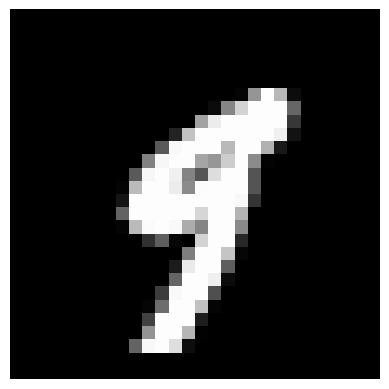

'9'

In [3]:
import matplotlib.pyplot as plt

some_digit = X.iloc[36000]
some_digit_image = some_digit.values.reshape(28, 28)

plt.imshow(some_digit_image, cmap="gray")
plt.axis("off")
plt.show()

y.iloc[36000]

In [4]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [5]:
import numpy as np

shuffle_index = np.random.permutation(60000)

X_train, y_train = X_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

In [6]:
y_train_9 = (y_train == "9")
y_test_9 = (y_test == "9")

In [7]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_9)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [8]:
sgd_clf.predict([some_digit])

D:\PythonProjects\ML_edu\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([False])

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_9):
    clone_clf = clone(sgd_clf)

    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_9.iloc[train_index]

    X_test_folds = X_train.iloc[test_index]
    y_test_folds = y_train_9.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)

    print(n_correct / len(y_pred))

0.92005
0.92095
0.94455


In [10]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.9365 , 0.9438 , 0.94795])

In [11]:
from sklearn.base import BaseEstimator

class Never9Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_9_clf = Never9Classifier()

cross_val_score(never_9_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.9    , 0.90105, 0.9015 ])

In [12]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3)

In [13]:
from sklearn.metrics import confusion_matrix

con_mat = confusion_matrix(y_train_9, y_train_pred)

con_mat

array([[51997,  2054],
       [ 1381,  4568]])

In [20]:
from sklearn.metrics import precision_score, recall_score

print(f"Полнота предсказаний - {precision_score(y_train_9, y_train_pred)}")
print(f"Точность предсказаний - {recall_score(y_train_9, y_train_pred)}")

Полнота предсказаний - 0.6898218061008758
Точность предсказаний - 0.7678601445621113


In [15]:
from sklearn.metrics import f1_score

print(f"Финальная точность предсказаний - {f1_score(y_train_9, y_train_pred)}")

Финальная точность предсказаний - 0.7267520483652852


In [16]:
y_scores =  sgd_clf.decision_function([some_digit])

y_scores

D:\PythonProjects\ML_edu\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([-1230.24413282])

In [22]:
threshold = 0
y_some_digit_prediction = (y_scores > threshold)

y_some_digit_prediction

array([False, False, False, ..., False, False,  True], shape=(60000,))

In [18]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3, method="decision_function")

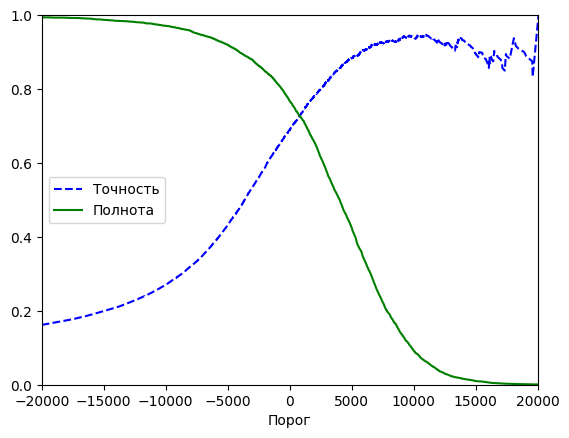

In [34]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_9, y_scores)

def plot_precision_recall_vs_threshold(_precisions, _recalls, _thresholds):
    plt.plot(_thresholds, _precisions[:-1], "b--", label="Точность")
    plt.plot(_thresholds, _recalls[:-1], "g-", label="Полнота")
    plt.xlabel("Порог")
    plt.legend(loc="center left")
    plt.ylim([0, 1])
    plt.xlim([-20000, 20000])

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [32]:
idx = np.argmax(precisions >= 0.9)
recall_at_90_precision = thresholds[idx]

recall_at_90_precision

np.float64(5685.618352216268)

In [36]:
y_train_pred_90 = (y_scores > recall_at_90_precision)

print(f"Полнота предсказаний - {precision_score(y_train_9, y_train_pred_90)}")
print(f"Точность предсказаний - {recall_score(y_train_9, y_train_pred_90)}")
print(f"Финальная точность предсказаний - {f1_score(y_train_9, y_train_pred_90)}")

Полнота предсказаний - 0.9002483443708609
Точность предсказаний - 0.3656076651538074
Финальная точность предсказаний - 0.5200239091452481


In [43]:
import joblib

joblib.dump(sgd_clf, "sgd_clf.pkl")

['sgd_clf.pkl']

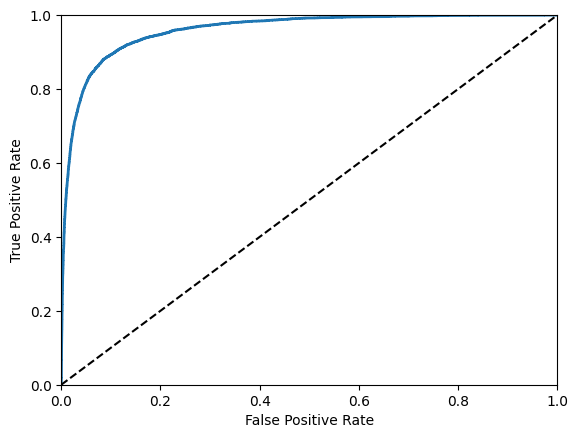

In [45]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_9, y_scores)

def plot_roc_curve(_fpr, _tpr, label=None):
    plt.plot(_fpr, _tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], "k--")
    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

plot_roc_curve(fpr, tpr, label="AUC = 0.95")
plt.show()

In [46]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_9, y_scores)

0.9593290205465443

In [48]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_9, cv=3, method="predict_proba")

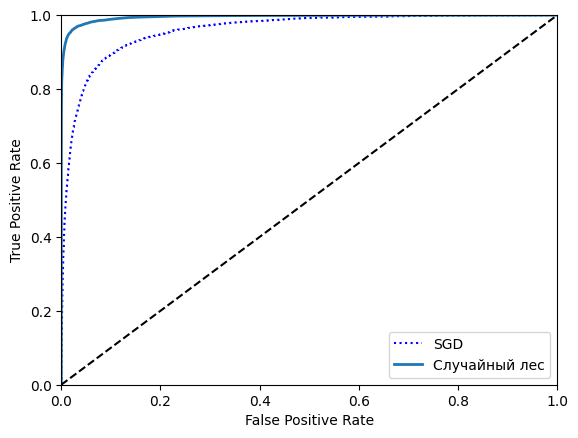

In [49]:
y_scores_forest = y_probas_forest[:, 1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_9, y_scores_forest)

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Случайный лес")
plt.legend(loc="lower right")
plt.show()

In [52]:
roc_auc_score(y_train_9, y_scores_forest)

0.995301326935461

In [53]:
joblib.dump(forest_clf, "forest_clf.pkl")

['forest_clf.pkl']